# Contextual Associative Bandits [CAB]

## Part 1: Defining The Inference System

In [1]:
import torch
from pathlib import Path

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np
import pickle
import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm
import gc

In [2]:
from idealobserver import IdealObsPFJCRP
from experiment import (
    ExperimentalCRP,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from utils_mcl import extract_context_params

## Part 1: Load experiment statistics from simulations

In [3]:
mcl_results_path = Path("mcl_results")
results_folder = (
    mcl_results_path
    / "prepost_static_ys_one_h_init_rho_dim_1_tc_dim_3"
    / "fourth_pass2_sim"
)
results_dcoin_folder = results_folder / "dCOIN" / "cab_nig"
results_dcoin_folder.mkdir(parents=True, exist_ok=True)

In [4]:
observations = np.load(results_folder / "stimuli")
T, B, _ = observations.shape
B = 100

contexts = np.loadtxt(results_folder / "ctxs")
# Context length: number of consecutive timesteps for each context
changes = np.where(contexts[1:] != contexts[:-1])[0] + 1
ctx_length = changes[0] if len(changes) > 0 else T

# Optional: verify that transitions are regular
if len(changes) > 1:
    lengths = np.diff(np.concatenate(([0], changes, [T])))
    if not np.all(lengths == ctx_length):
        raise ValueError(f"Context transitions are not regular: {lengths}")
n_blocks = int(T / (ctx_length * 2))
b = 10

## Part 2: Run Simulation

In [5]:
# HYP_JCRP = {
#     "gamma": 0.1,
#     "alpha": 0.5,
# }
# HYP_NIW = {
#     "mu0": torch.tensor([0.0, 0.0]),
#     "kappa0": 0.1,
#     "nu0": 4.0,
#     "Lambda0": torch.eye(2) * 1.0,
# }

HYP_JCRP = {
    "gamma": 0.05,
    "alpha": 10,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.05,
    "alpha0": 10.0,
    "beta0": 1.0,
}

HYP_BB = {
    "beta0": torch.tensor([0.25, 0.25, 0.25, 0.25]),
    "rho_c": 0.9,
    "rho_i": 0.1,
}

HYP = {"hyp_jcrp": HYP_JCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}
N_particles = 250

#### Simulation

In [6]:
n_per_episode = 10

Batch 0:   0%|          | 0/10 [00:00<?, ?it/s]

i=0:   0%|          | 0/10 [00:00<?, ?it/s]

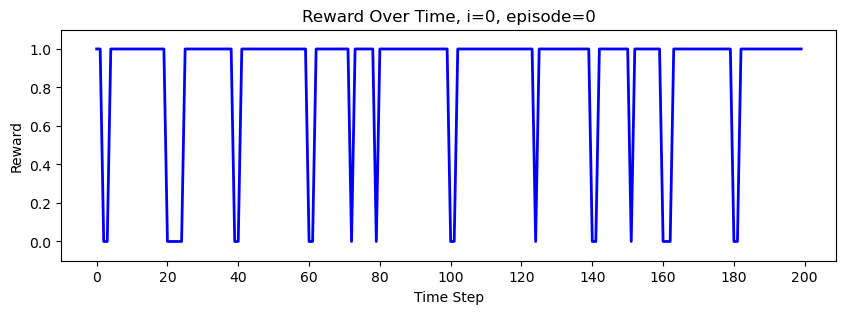

i=1:   0%|          | 0/10 [00:00<?, ?it/s]

i=2:   0%|          | 0/10 [00:00<?, ?it/s]

i=3:   0%|          | 0/10 [00:00<?, ?it/s]

i=4:   0%|          | 0/10 [00:00<?, ?it/s]

i=5:   0%|          | 0/10 [00:00<?, ?it/s]

...

i=18:   0%|          | 0/10 [00:00<?, ?it/s]

i=19:   0%|          | 0/10 [00:00<?, ?it/s]

Saved batch 1: i=10:20 -> mcl_results/prepost_static_ys_one_h_init_rho_dim_1_tc_dim_3/fourth_pass2_sim/dCOIN/cab_nig/results_10_20.pkl


Batch 2:   0%|          | 0/10 [00:00<?, ?it/s]

i=20:   0%|          | 0/10 [00:00<?, ?it/s]

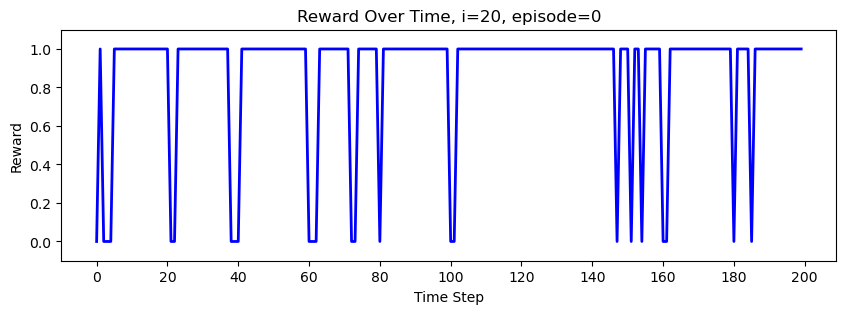

i=21:   0%|          | 0/10 [00:00<?, ?it/s]

i=22:   0%|          | 0/10 [00:00<?, ?it/s]

i=23:   0%|          | 0/10 [00:00<?, ?it/s]

i=24:   0%|          | 0/10 [00:00<?, ?it/s]

i=25:   0%|          | 0/10 [00:00<?, ?it/s]

...

i=38:   0%|          | 0/10 [00:00<?, ?it/s]

i=39:   0%|          | 0/10 [00:00<?, ?it/s]

Saved batch 3: i=30:40 -> mcl_results/prepost_static_ys_one_h_init_rho_dim_1_tc_dim_3/fourth_pass2_sim/dCOIN/cab_nig/results_30_40.pkl


Batch 4:   0%|          | 0/10 [00:00<?, ?it/s]

i=40:   0%|          | 0/10 [00:00<?, ?it/s]

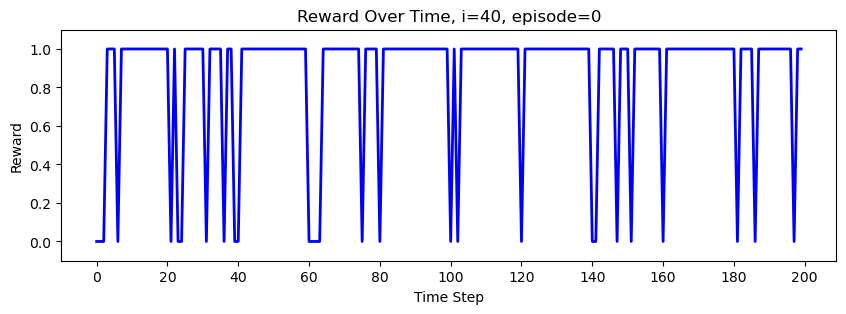

i=41:   0%|          | 0/10 [00:00<?, ?it/s]

i=42:   0%|          | 0/10 [00:00<?, ?it/s]

Process SpawnProcess-3364:
Process SpawnProcess-3366:
Process SpawnProcess-3368:
Process SpawnProcess-3367:
Process SpawnProcess-3362:
Process SpawnProcess-3363:
Process SpawnProcess-3361:
Process SpawnProcess-3365:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/youjingyu/code/CCAB/idealobserver.py", line 61, in pf_worker_loop
    particle.before_action(o_t)
  File "/Users/youjingyu/code/CCAB/particle.py", line 609, in before_action
    self.p_jump_o = torch.clamp(
                    ^^^^^^^^^^^^
KeyboardInterrupt
  File "/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/youjingyu/anaconda

KeyboardInterrupt: 

In [8]:
print_level = 0

start = 0

for batch_idx in range((B + b - 1) // b):

    end = min(start + b, B)

    # Store everything belonging to this batch
    batch_results = {
        "batch_idx": batch_idx,
        "start": start,
        "end": end,
        "results": {},
    }

    for i in tqdm(range(start, end), desc=f"Batch {batch_idx}"):

        # Store episodes for this i
        batch_results["results"][i] = {}

        for ep in tqdm(
            range(n_per_episode),
            desc=f"i={i}",
            leave=False,
        ):

            # Initialize history buffers
            exp_history = ExperimentHistory()
            sub_history = IOPFSubjectHistory()

            contexts, states, observations, context_r_params = extract_context_params(
                results_folder,
                episode_idx=0,
            )

            env = ExperimentalCRP(
                context_r_params=context_r_params,
                contexts=contexts,
                states=states,
                observations=observations,
            )

            # Initialize ensemble
            subject = IdealObsPFJCRP(
                N=N_particles,
                hyp_params=HYP,
                n_workers=8,
            )

            env.episode(
                subject,
                experiment_history=exp_history,
                subject_history=sub_history,
                print_level=print_level,
            )

            subject.deallocate()

            combined_history = CombinedHistory(
                subject_history=sub_history,
                experiment_history=exp_history,
            )

            # ------------------------------------------------
            # SAVE RESULT WITH BOTH INDICES
            # ------------------------------------------------
            batch_results["results"][i][ep] = combined_history

            if i % 20 == 0 and ep == 0:
                plt.figure(figsize=(10, 3))
                plt.plot(
                    combined_history.experiment_history.reward,
                    label="Reward",
                    color="blue",
                    linewidth=2,
                )
                plt.title(f"Reward Over Time, i={i}, episode={ep}")
                plt.xlabel("Time Step")
                plt.ylabel("Reward")
                plt.xticks(range(0, T + 1, ctx_length))
                plt.ylim(-0.1, 1.1)
                plt.show()

            # Explicitly remove temporary references
            del combined_history
            del exp_history
            del sub_history
            del env
            del subject

    # --------------------------------------------------------
    # SAVE THIS BATCH
    # --------------------------------------------------------
    res_name = f"results_{start}_{end}"

    output_file = results_dcoin_folder / f"{res_name}.pkl"

    with open(output_file, "wb") as f:
        pickle.dump(
            batch_results,
            f,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    print(f"Saved batch {batch_idx}: " f"i={start}:{end} -> {output_file}")

    # Free batch
    del batch_results
    gc.collect()

    start = end

In [ ]:
proportion_optimal_mean = np.zeros(T)
n_batches = 0
for start in range(0, B, b):

    end = min(start + b, B)
    filename = f"results_{start}_{end}.pkl"

    print(f"Loading {filename}")

    with open(results_dcoin_folder / filename, "rb") as f:
        batch = pickle.load(f)

    # -------------------------------------------------------
    # Average episodes for each batch index i
    # -------------------------------------------------------
    batch_mean = np.zeros(T)
    n_batch_indices = 0

    for batch_idx, episodes in batch["results"].items():

        # Average reward across episodes for this i
        idx_mean = np.zeros(T)

        for ep, result in episodes.items():
            idx_mean += np.asarray(result.experiment_history.reward)

        idx_mean /= len(episodes)

        # Add the mean for this i
        batch_mean += idx_mean
        n_batch_indices += 1

    # -------------------------------------------------------
    # Average over batch indices
    # -------------------------------------------------------
    batch_mean /= n_batch_indices

    # -------------------------------------------------------
    # Add this batch's mean to the global mean
    # -------------------------------------------------------
    proportion_optimal_mean += batch_mean
    n_batches += 1

    del batch

# -----------------------------------------------------------
# Average equally over batches
# -----------------------------------------------------------
proportion_optimal_mean /= n_batches

Loading results_0_10.pkl
Loading results_10_20.pkl
Loading results_20_30.pkl
Loading results_30_40.pkl


In [11]:
from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


smooth_plot = False

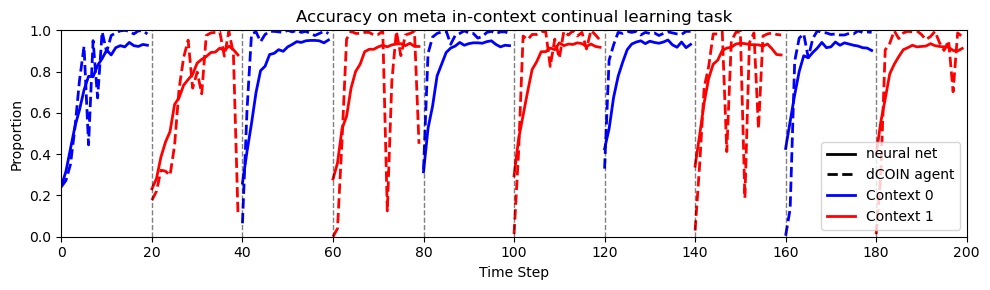

In [12]:
acc = np.loadtxt(results_folder / "acc")

plt.figure(figsize=(10, 3))

for start in range(0, T, ctx_length):
    end = min(start + ctx_length, T)
    duration = np.arange(start, end)

    # Alternate blue/red by context
    color = "blue" if (start // ctx_length) % 2 == 0 else "red"

    # Task: dashed
    if smooth_plot:
        task = smooth(proportion_optimal_mean[start:end])
        acc_tmp = smooth(acc[start:end])
    else:
        task = proportion_optimal_mean[start:end]
        acc_tmp = acc[start:end]
    plt.plot(
        duration,
        task,
        color=color,
        linestyle="--",
        linewidth=2,
    )

    # Agent accuracy: solid
    plt.plot(
        duration,
        acc_tmp,
        color=color,
        linestyle="-",
        linewidth=2,
    )

    # Task switch
    if start > 0:
        plt.axvline(
            start,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )

plt.title("Accuracy on meta in-context continual learning task")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xticks(range(0, T + 1, ctx_length))

# Legend: line styles
plt.plot([], [], color="black", linestyle="-", linewidth=2, label="neural net")
plt.plot([], [], color="black", linestyle="--", linewidth=2, label="dCOIN agent")


# Legend: contexts
plt.plot([], [], color="blue", linewidth=2, label="Context 0")
plt.plot([], [], color="red", linewidth=2, label="Context 1")

plt.legend()
plt.tight_layout()
plt.show()

## Part 3: Analysis of Results

### Visualisation of Results

In [ ]:
res_name = "results_0_2"

In [ ]:
with open(results_dcoin_folder / f"{res_name}.pkl", "rb") as f:
    results = pickle.load(f)

Context History:


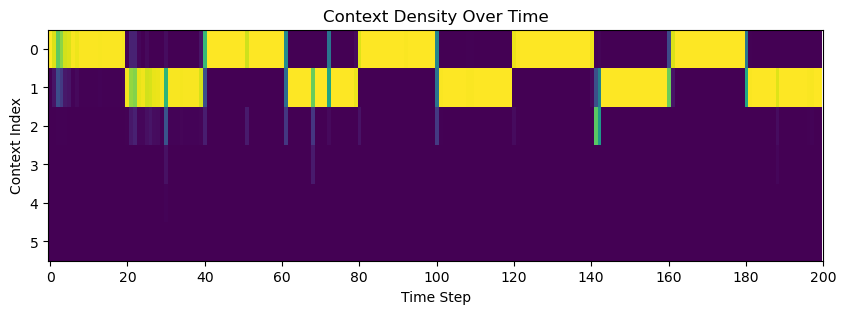

Actions History:


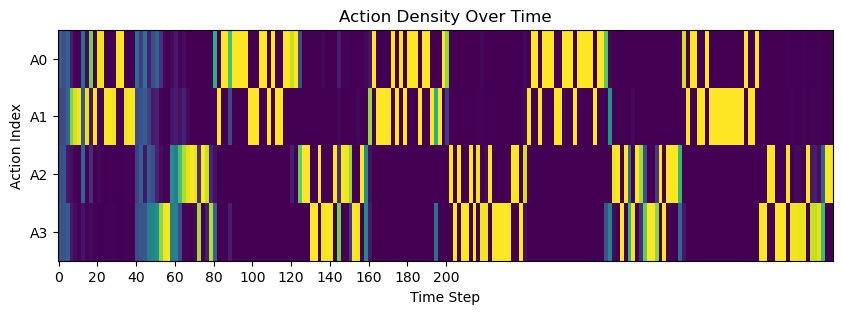

Proportion of Optimal Actions Over Time:


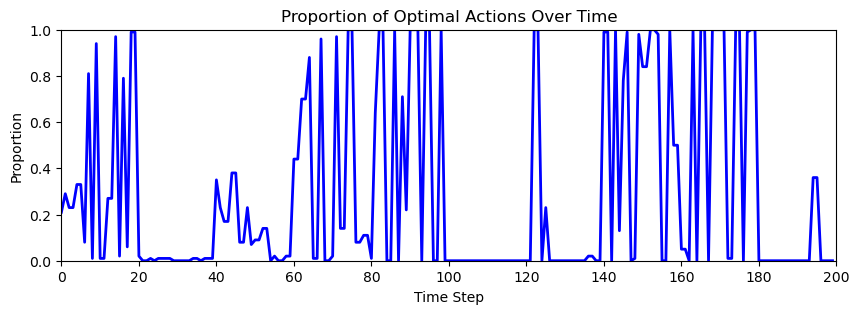

Jump History:


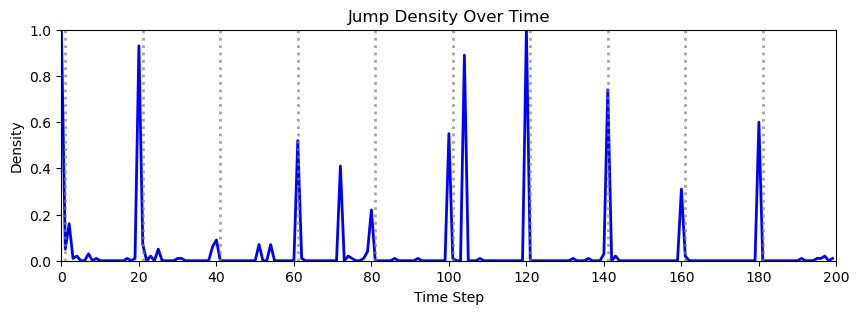

Inferred S History:


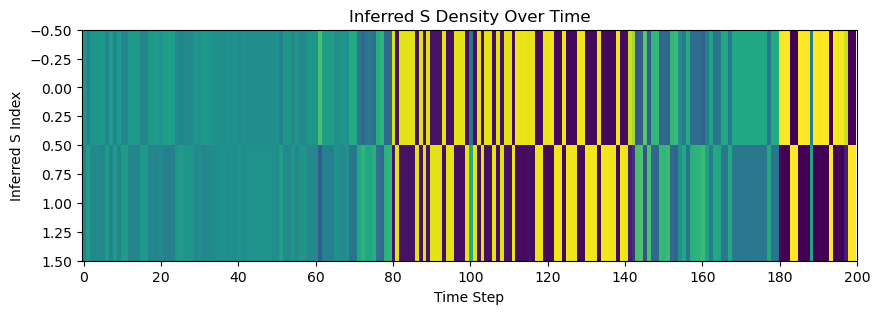

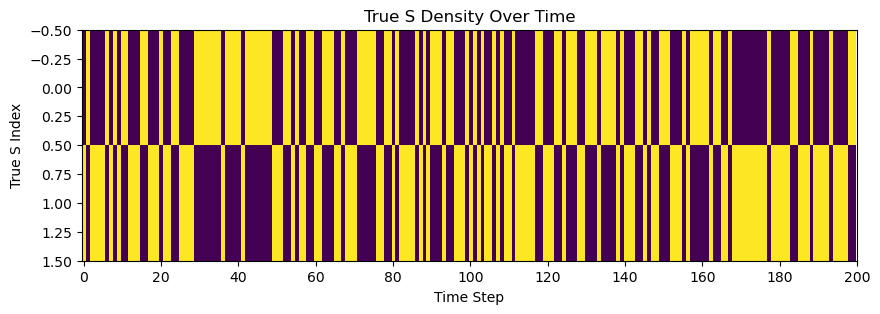

In [ ]:
# jump_times = []
# j = 0
# context_o_hist_arr = np.array(results[j].subject_history.context_o)
# context_r_hist_arr = np.array(results[j].subject_history.context_r)
# p_actions_arr = np.array(results[j].subject_history.p_action)
# p_jump_arr = np.array(results[j].subject_history.p_jump)
# p_state_arr = np.array(results[j].subject_history.p_state)
# weight_arr = np.array(results[j].subject_history.weights)
# p_action_optimal = results[j].p_optimal_action

i = 0
ep = 0

result = results["results"][i][ep]

jump_times = []

context_o_hist_arr = np.array(result.subject_history.context_o)
context_r_hist_arr = np.array(result.subject_history.context_r)

p_actions_arr = np.array(result.subject_history.p_action)
p_jump_arr = np.array(result.subject_history.p_jump)
p_state_arr = np.array(result.subject_history.p_state)

weight_arr = np.array(result.subject_history.weights)

p_action_optimal = result.p_optimal_action

print("Context History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context Density Over Time")
# plt.savefig("g_context_o_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()


print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
for i in range(1, 201, 20):
    plt.axvline(i, color="grey", linestyle=":", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)

plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(result.experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, int(val)] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_true_s_density.pdf")
plt.show()